In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re as r

In [2]:
path = r'C:\Users\ACER\Documents\datathon-2026-round-1\Datathon_Contest_UITUT\Data' 

# 2. Lấy danh sách tất cả các file trong thư mục
files = [f for f in os.listdir(path) if f.endswith('.csv')]

for file in files:
    # Tách tên file và phần mở rộng (vd: 'data.csv' -> 'data')
    file_name = os.path.splitext(file)[0]
    
    # Tạo đường dẫn đầy đủ
    full_path = os.path.join(path, file)
    
    # Đọc file và gán vào biến có tên df_tên_file
    # globals() giúp tạo biến động trong môi trường hiện tại
    globals()[f"df_{file_name}"] = pd.read_csv(full_path)
    
    print(f"Đã load xong: df_{file_name}")

Đã load xong: df_customers
Đã load xong: df_geography
Đã load xong: df_inventory
Đã load xong: df_orders


C:\Users\ACER\AppData\Local\Temp\ipykernel_67460\3359505436.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  globals()[f"df_{file_name}"] = pd.read_csv(full_path)


Đã load xong: df_order_items
Đã load xong: df_payments
Đã load xong: df_products
Đã load xong: df_promotions
Đã load xong: df_returns
Đã load xong: df_reviews
Đã load xong: df_sales
Đã load xong: df_sample_submission
Đã load xong: df_shipments
Đã load xong: df_web_traffic


In [3]:
df_sales

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


--- ĐÁNH GIÁ MÔ HÌNH ---
MAE:  611,733 VND
RMSE: 907,637 VND
R2 Score: 0.7060 (70.60%)


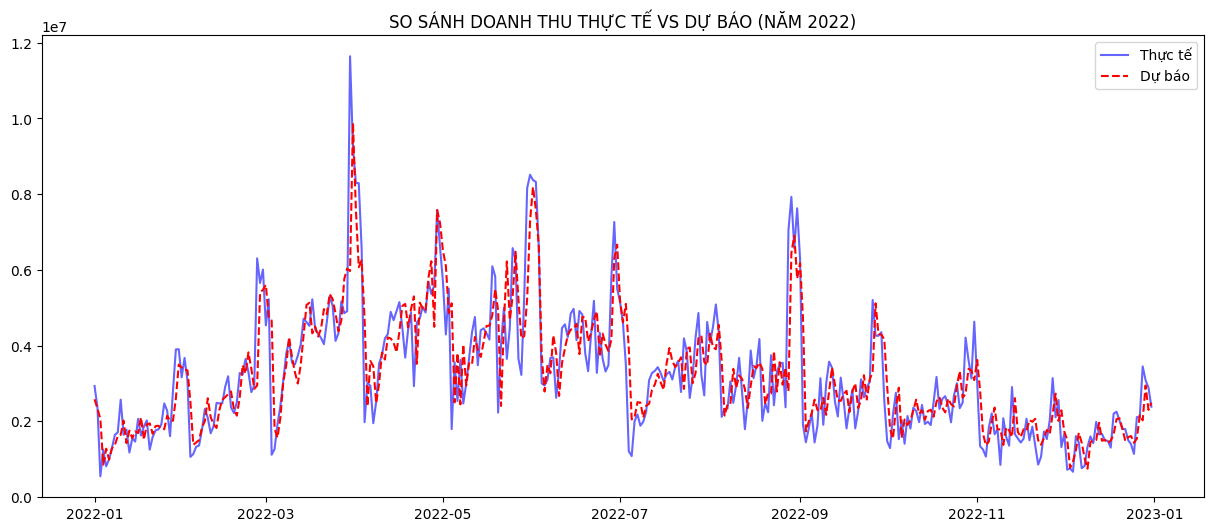


--- ĐỘ QUAN TRỌNG CỦA CÁC YẾU TỐ ---
| feature         |   importance |
|:----------------|-------------:|
| rev_lag_1       |    0.757221  |
| rev_lag_7       |    0.0596979 |
| rev_roll_mean_7 |    0.0454748 |
| rev_lag_30      |    0.0445484 |
| day_of_week     |    0.0269154 |
| month           |    0.0267148 |
| sessions        |    0.0235235 |
| bounce_rate     |    0.0159039 |
| quarter         |    0         |
| is_weekend      |    0         |


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU GỐC (MASTER DATA)
# ==========================================
# Giả sử df_sales đã có cột Date và Revenue
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Lấp đầy các ngày bị thiếu trong lịch sử
all_dates = pd.date_range(start=df_sales['Date'].min(), end=df_sales['Date'].max(), freq='D')
df_model = df_sales.set_index('Date').reindex(all_dates).reset_index().rename(columns={'index': 'Date'})
df_model['Revenue'] = df_model['Revenue'].ffill()

# ==========================================
# 2. NHÉT FACTORS (EXOGENOUS VARIABLES)
# ==========================================
# Nối thêm Web Traffic
if 'df_web_traffic' in globals():
    df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
    df_model = df_model.merge(df_web_traffic[['date', 'sessions', 'bounce_rate']], 
                              left_on='Date', right_on='date', how='left').drop(columns='date')
    df_model[['sessions', 'bounce_rate']] = df_model[['sessions', 'bounce_rate']].fillna(0)

# Nối thêm Promotions (Ví dụ: tạo cột is_promo nếu có đơn hàng dùng mã giảm giá)
if 'df_order_items' in globals():
    promo_dates = df_order_items[df_order_items['promo_id'].notna()]['order_id'].unique()
    # (Giả định ông đã merge với df_orders để lấy ngày có promo)
    # Tạm thời tạo biến giả lập nếu chưa xử lý xong bảng promo
    df_model['is_promo'] = 0 

# ==========================================
# 3. FEATURE ENGINEERING (CHẾ BIẾN BIẾN)
# ==========================================
def create_features(df):
    df = df.copy()
    # Time features
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['quarter'] = df['Date'].dt.quarter
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    # Lag features (Dữ liệu quá khứ)
    df['rev_lag_1'] = df['Revenue'].shift(1)
    df['rev_lag_7'] = df['Revenue'].shift(7)
    df['rev_lag_30'] = df['Revenue'].shift(30)
    
    # Rolling features (Trung bình trượt)
    df['rev_roll_mean_7'] = df['Revenue'].shift(1).rolling(window=7).mean()
    
    return df

df_model = create_features(df_model)
df_model = df_model.dropna() # Bỏ những dòng đầu bị NaN do shift

# ==========================================
# 4. CHIA TRAIN - TEST (CẮT THEO THỜI GIAN)
# ==========================================
# Lấy năm cuối cùng làm Test, còn lại làm Train
split_date = '2022-01-01'
train = df_model[df_model['Date'] < split_date]
test = df_model[df_model['Date'] >= split_date]

features = ['day_of_week', 'month', 'quarter', 'is_weekend', 
            'rev_lag_1', 'rev_lag_7', 'rev_lag_30', 'rev_roll_mean_7',
            'sessions', 'bounce_rate'] # Thêm các factor vào đây
target = 'Revenue'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# ==========================================
# 5. TRAIN MODEL XGBOOST
# ==========================================
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, early_stopping_rounds=50)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Dự báo
y_pred = model.predict(X_test)

# ==========================================
# 6. ĐÁNH GIÁ & VẼ BIỂU ĐỒ
# ==========================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- ĐÁNH GIÁ MÔ HÌNH ---")
print(f"MAE:  {mae:,.0f} VND")
print(f"RMSE: {rmse:,.0f} VND")
print(f"R2 Score: {r2:.4f} ({r2*100:.2f}%)")


plt.figure(figsize=(15, 6))
plt.plot(test['Date'], y_test, label='Thực tế', color='blue', alpha=0.6)
plt.plot(test['Date'], y_pred, label='Dự báo', color='red', linestyle='--')
plt.title('SO SÁNH DOANH THU THỰC TẾ VS DỰ BÁO (NĂM 2022)')
plt.legend()
plt.show()

# Kiểm tra xem Factor nào quan trọng nhất
importance = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
print("\n--- ĐỘ QUAN TRỌNG CỦA CÁC YẾU TỐ ---")
print(importance.sort_values('importance', ascending=False).to_markdown(index=False))